# Introducción

# Exploratory Data Analysis

Empezaremos por analizar la data proporcionada para poder sacar información relevante para el pre-procesado y modelaje.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import joblib
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def nl():
    print('\n')


# Helper function to format tables
def show_df(df, precision=2, width="100%", percent_cols=None):
    styler = (
        df.style
        .format(precision=precision, na_rep="NaN")
        .set_table_attributes(f'style="width:{width}"')
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px")]},
        ])
        .hide(axis="index")
    )

    if percent_cols:
        styler = styler.format({c: "{:.2f}%" for c in percent_cols})

    display(styler)


print("Datasets:")
!ls ../data

Datasets:
stars_data.csv


Tenemos el fichero `stars_data.csv` empecemos por analizarlo

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [2]:
df = pd.read_csv('../data/stars_data.csv')

print('Tamaño del dataset: ', str(df.shape))
print('Columnas: ', str(df.columns.values.tolist()))

Tamaño del dataset:  (240, 6)
Columnas:  ['Temperature', 'L', 'R', 'A_M', 'Color', 'Spectral_Class']


Hay 6 features y 240 filas para usar en nuestro entrenamiento.

## Esquema de Variables

In [3]:
summary = pd.DataFrame({
    "Feature": df.columns,
    "dtype": df.dtypes,
    "Unique Values": df.nunique(dropna=True).tolist(),

})
show_df(summary)

n = len(df)
constant_cols = df.columns[df.nunique() <= 1].tolist()
id_cols = df.columns[df.nunique() == n].tolist()

print("Constant columns:", constant_cols if constant_cols else "None")
print("Potential ID columns:", id_cols if id_cols else "None")

Feature,dtype,Unique Values
Temperature,int64,228
L,float64,208
R,float64,216
A_M,float64,228
Color,str,17
Spectral_Class,str,7


Constant columns: None
Potential ID columns: None


Podemos observar que tenemos 1 clase con números enteros, 3 con números single-precision y 2 categóricas de tipo string.

Procederé a analizarlas a mayor detalle, buscando entender como se distribuyen y en cuáles vale la pena indagar más a profundidad después.

### Variables Categóricas

Nos interesa saber su cardinalidad, si hay desbalances en las distribuciones, cúal es la categória dominante y si les faltan valores.

In [4]:
cat = df.select_dtypes(include="str")

rows = []

for col in cat.columns:
    freq = (cat[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    categories = ["NaN" if pd.isna(x) else x for x in freq.index]
    dist = [f"({catg}, {pct}%)" for catg, pct in zip(categories, freq.tolist())]

    rows.append(", ".join(dist))

summary = pd.DataFrame({
    "Feature": cat.columns,
    "n_categories": cat.nunique(dropna=True).tolist(),
    "missing_values": cat.isnull().sum().tolist(),
    "missing_values %": (cat.isnull().mean() * 100).round(2).values,
    "category_distribution_top": rows,
})

summary = summary.sort_values("n_categories", ascending=False)

show_df(summary)

Feature,n_categories,missing_values,missing_values %,category_distribution_top
Color,17,0,0.00,"(Red, 46.67%), (Blue, 23.33%), (Blue-white, 10.83%), (Blue White, 4.17%), (yellow-white, 3.33%), (White, 2.92%), (Blue white, 1.67%), (Yellowish White, 1.25%), (white, 1.25%), (Whitish, 0.83%), (Orange, 0.83%), (yellowish, 0.83%), (Pale yellow orange, 0.42%), (White-Yellow, 0.42%), (Yellowish, 0.42%), (Orange-Red, 0.42%), (Blue-White, 0.42%)"
Spectral_Class,7,0,0.00,"(M, 46.25%), (B, 19.17%), (O, 16.67%), (A, 7.92%), (F, 7.08%), (K, 2.5%), (G, 0.42%)"


Observaciones:
* No hay valores faltantes o clases extrañas como "unknown"
* En `Color`, la clase mayoritaria es Red (46.67%), luego Blue (23.33). Notamos un desbalance alto, con clases como Blue-White, Orange-Red, Yellowish, White-Yellow y Pale yellow orange con 0.42% de presencia.
* `Spectral_Class` también tiene un desbalance marcado, con M como clase mayoritaria (46.25%) y G como clase minoritaria (0.42%).

`Color` presenta inconsistencias en los valores categóricos, variantes de capitalización y formato representan la misma categoría física (ej. "Blue White", "Blue white", "Blue-white", "Blue-White"). Limpiemos estas categorías antes de continuar.


In [5]:
df['Color'] = df['Color'].str.strip().str.lower().str.replace('-', ' ')
df['Color'] = df['Color'].replace({
    'yellowish white': 'yellow white',
    'white yellow': 'yellow white',
    'yellowish': 'yellow white',
    'whitish': 'white',
    'pale yellow orange': 'orange',
    'orange red': 'orange',
})
color_clean = df['Color'].value_counts().reset_index()
color_clean.columns = ['Color', 'Count']
color_clean['%'] = (color_clean['Count'] / color_clean['Count'].sum() * 100).round(2)
cat = df.select_dtypes(include="str")
show_df(color_clean)

Color,Count,%
red,112,46.67
blue,56,23.33
blue white,41,17.08
yellow white,15,6.25
white,12,5.00
orange,4,1.67




# Variables Numéricas

Feature,NULL,Min,Max,Range,STD,Skewness,Kurtosis,Mean,Median
Temperature,0,1939.00,40000.00,38061.00,9552.43,1.32,0.88,10497.46,5776.00
L,0,0.00,849420.00,849420.00,179432.24,2.07,4.47,107188.36,0.07
R,0,0.01,1948.50,1948.49,517.16,1.95,2.07,237.16,0.76
A_M,0,-11.92,20.06,31.98,10.53,-0.12,-1.66,4.38,8.31


Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outliers (%)
R,0.10,42.75,42.65,-63.87,106.72,40,16.67
L,0.00,198050.00,198050.00,-297075.00,495125.00,12,5.00
Temperature,3344.25,15055.50,11711.25,-14222.62,32622.38,11,4.58
A_M,-6.23,13.70,19.93,-36.13,43.59,0,0.00


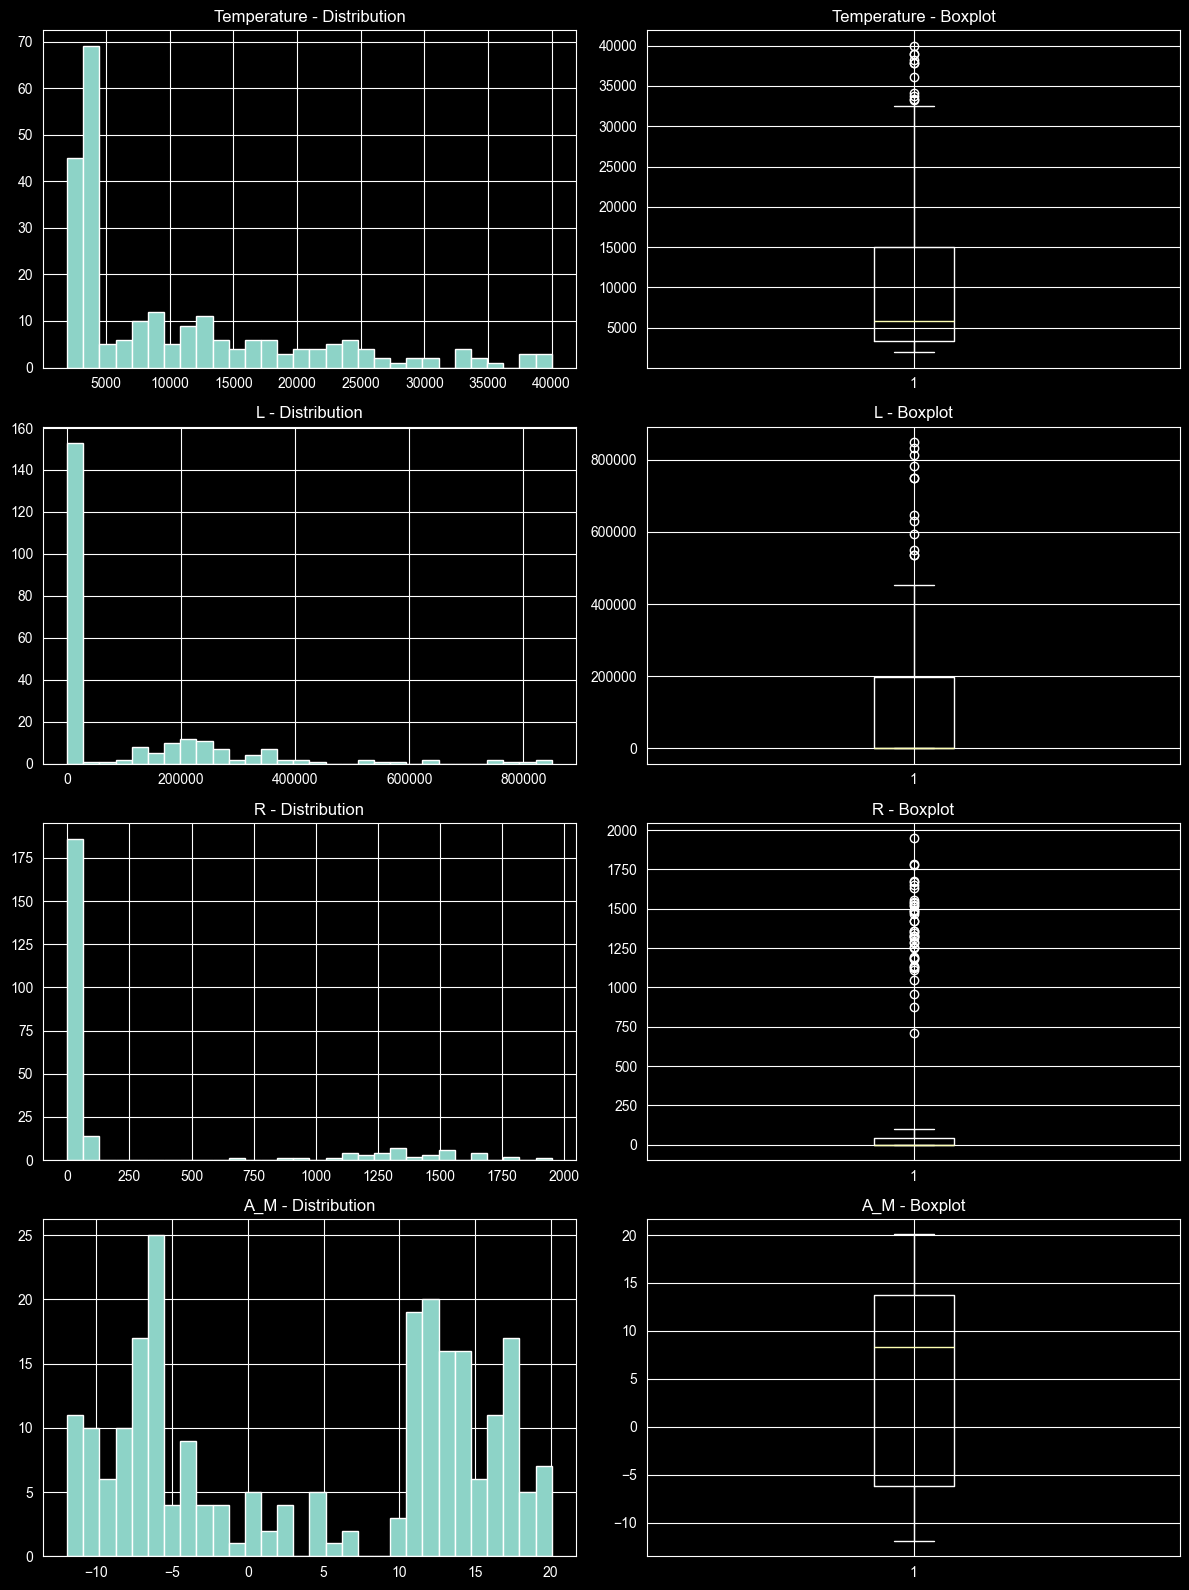

In [6]:
num = df.select_dtypes(include="number" )


def outlier_info_iqr(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": mask.sum(),
        "Outliers (%)": mask.mean() * 100
    }


summary = pd.DataFrame({
    "Feature": num.columns,
    "NULL": num.isnull().sum(),
    "Min": [num[col].min() for col in num.columns],
    "Max": [num[col].max() for col in num.columns],
    "Range": [num[col].max() - num[col].min() for col in num.columns],
    "STD": [num[col].std() for col in num.columns],
    "Skewness": [num[col].skew() for col in num.columns],
    "Kurtosis": [num[col].kurtosis() for col in num.columns],
    "Mean": [num[col].mean() for col in num.columns],
    "Median": [num[col].median() for col in num.columns],
})

show_df(summary)

outlier_table = pd.DataFrame([
    {"Feature": col, **outlier_info_iqr(num[col])}
    for col in num.columns
])

show_df(outlier_table.sort_values("Outliers (%)", ascending=False))

fig, axes = plt.subplots(len(num.columns), 2, figsize=(12, 4 * len(num.columns)))

for i, col in enumerate(num.columns):
    # Distribución
    axes[i, 0].hist(num[col], bins=30)
    axes[i, 0].set_title(f'{col} - Distribution')

    # Boxplot para outliers
    axes[i, 1].boxplot(num[col])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()


Observaciones:
* Hay gran diferencia entre las escalas. `L` tiene un rango y desviación mayor que el resto, luego viene `Temperature`. `A_M` es mucho más reducido, teniendo un rango ~26000 veces más pequeño que `L`.
* `L` y `R` tienen asimetría positiva y kurtosis elevada. Esta concentración que se forma alrededor de 0 muestra que nuestra data es probablemente multimodal, con poblaciones distintas mezcladas. Podemos comenzar a notar clusters naturales. Esto también ocurre con `Temperature`.
    * Los outliers detectados por IQR pueden corresponder a poblaciones poco frecuentes, no a errores o ruido en los datos.
* `A_M` claramente tien una distribución bimodal, con dos picos separados en ~-7 y ~12. Podemos observar una separación entre estrellas brillantes y tenues.

Con estas observaciones en mente, pasemos a analizar la relación inter-variable.

## Análisis Inter-Variable

Nos interesa entender la correlación entre las variables.

### Correlación entre Numéricas


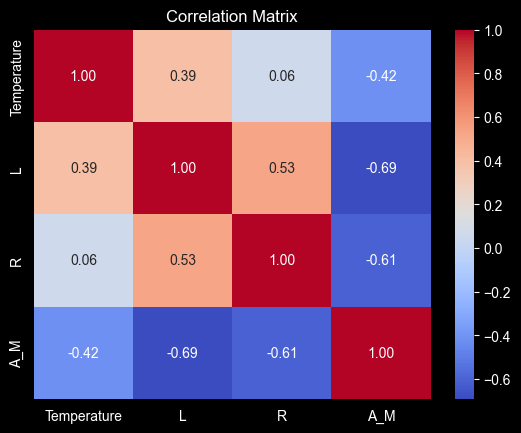

In [7]:
import seaborn as sns

corr = num.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Hay que tomar en cuenta que la magnitud absoluta es una escala invertida, mientras más alta, más tenue la estrella.

Observaciones:
* La mayor correlación es entre `L` y `A_M` (-0.69). Esto tiene sentido, una estrella luminosa a 10 parsec es brillante. Igual con `A_M` y `Temperature` (-0.42), y `A_M` y `R` (-0.61). En general mientras mayor son los otros valores, menor `A_M`, por lo que la estrella es más brillante.
* `L` y `R` están correlacionadas (0.53), como es de esperarse, mientras más grande la estrella, más luminosa.
* `L` y `Temperature` tienen una correlación baja (0.39). Usualmente, esperaríamos que estrellas calientes ejerzan mayor luminosidad. Esto lo analizaremos más a detalle.
* El tamaño de la estrella `R` no se relaciona con su temperatura `Temperature`, la relación es casi 0. Significa que en este dataset coexisten estrellas frías enormes y estrellas calientes pequeñas, eso es exactamente la diferencia entre una supergigante roja y una enana blanca.
    * Además, como `R` está tan correlacionado con `L`, la correlación entre `Temperature` y `L` es menor, ya que `L` no está dada por un solo factor.

### Temperature vs. L

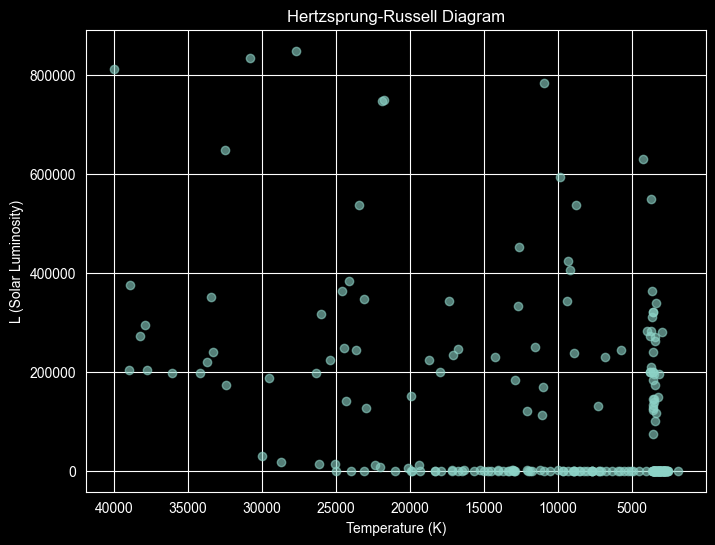

In [8]:
def show_hr_graph(log_transform=False):
    plt.figure(figsize=(8, 6))
    plt.scatter(df['Temperature'], df['L'], alpha=0.6)
    plt.xlabel('Temperature (K)')
    plt.ylabel('L (Solar Luminosity)')
    plt.title('Hertzsprung-Russell Diagram (Log Transformed)' if log_transform else 'Hertzsprung-Russell Diagram')
    plt.gca().invert_xaxis()  # Astronomic convention, temp. decreases to the right
    if log_transform:
        plt.yscale('log')
        plt.xscale('log')
    plt.show()

show_hr_graph()

Podemos observar como estrellas con la misma temperatura pueden tener una diferencia tan grande de luminosidad. Esto es porque `L` no solo está dado por `Temperature`, también puede ser `R` u otro factor que la afecta.

Ahora bien, hay un problema más serio. Todos nuestros datos están acoplados alrededor del 0 en `L`, esto no es bueno, ya que PCA verá solo las gigantes y supergigantes, el resto va a ser indistinguible, probemos verlo con log transform.

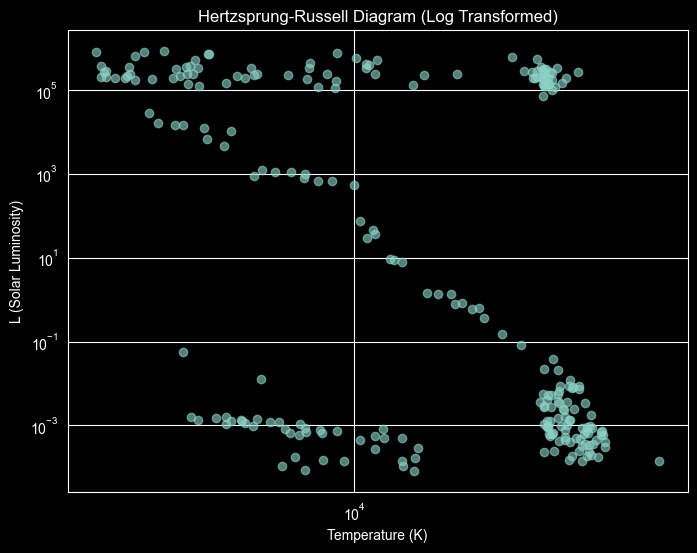

In [9]:
show_hr_graph(log_transform=True)

Ahora podemos observar una estructura más descriptiva. Podemos comenzar a notar clusters.

* La banda superior son las estrellas gigantescas, donde `R` es tan grande que la temperatura no influye. Por eso se forma una franja horizontal, la temperatura varia, pero la luminosidad sigue siendo gigantesca.
* Luego podemos observar una diagonal descendente, estas son estrellas que si dependen de temperatura, mientras mayor es, mayor su luminosidad.
* La nube de abajo a la derecha son estrellas frías y pequeñas, con poca luminosidad.
* El grupo disperso de abajo a la izquierda, son estrellas calientes, pero pequeñas, con poca luminosidad por su tamaño.

Estos 4 grupos se corresponden con los tipos conocidos: hipergigantes/supergigantes, secuencia principal, enanas rojas/marrones y enanas blancas.

### Categóricas vs. Numéricas

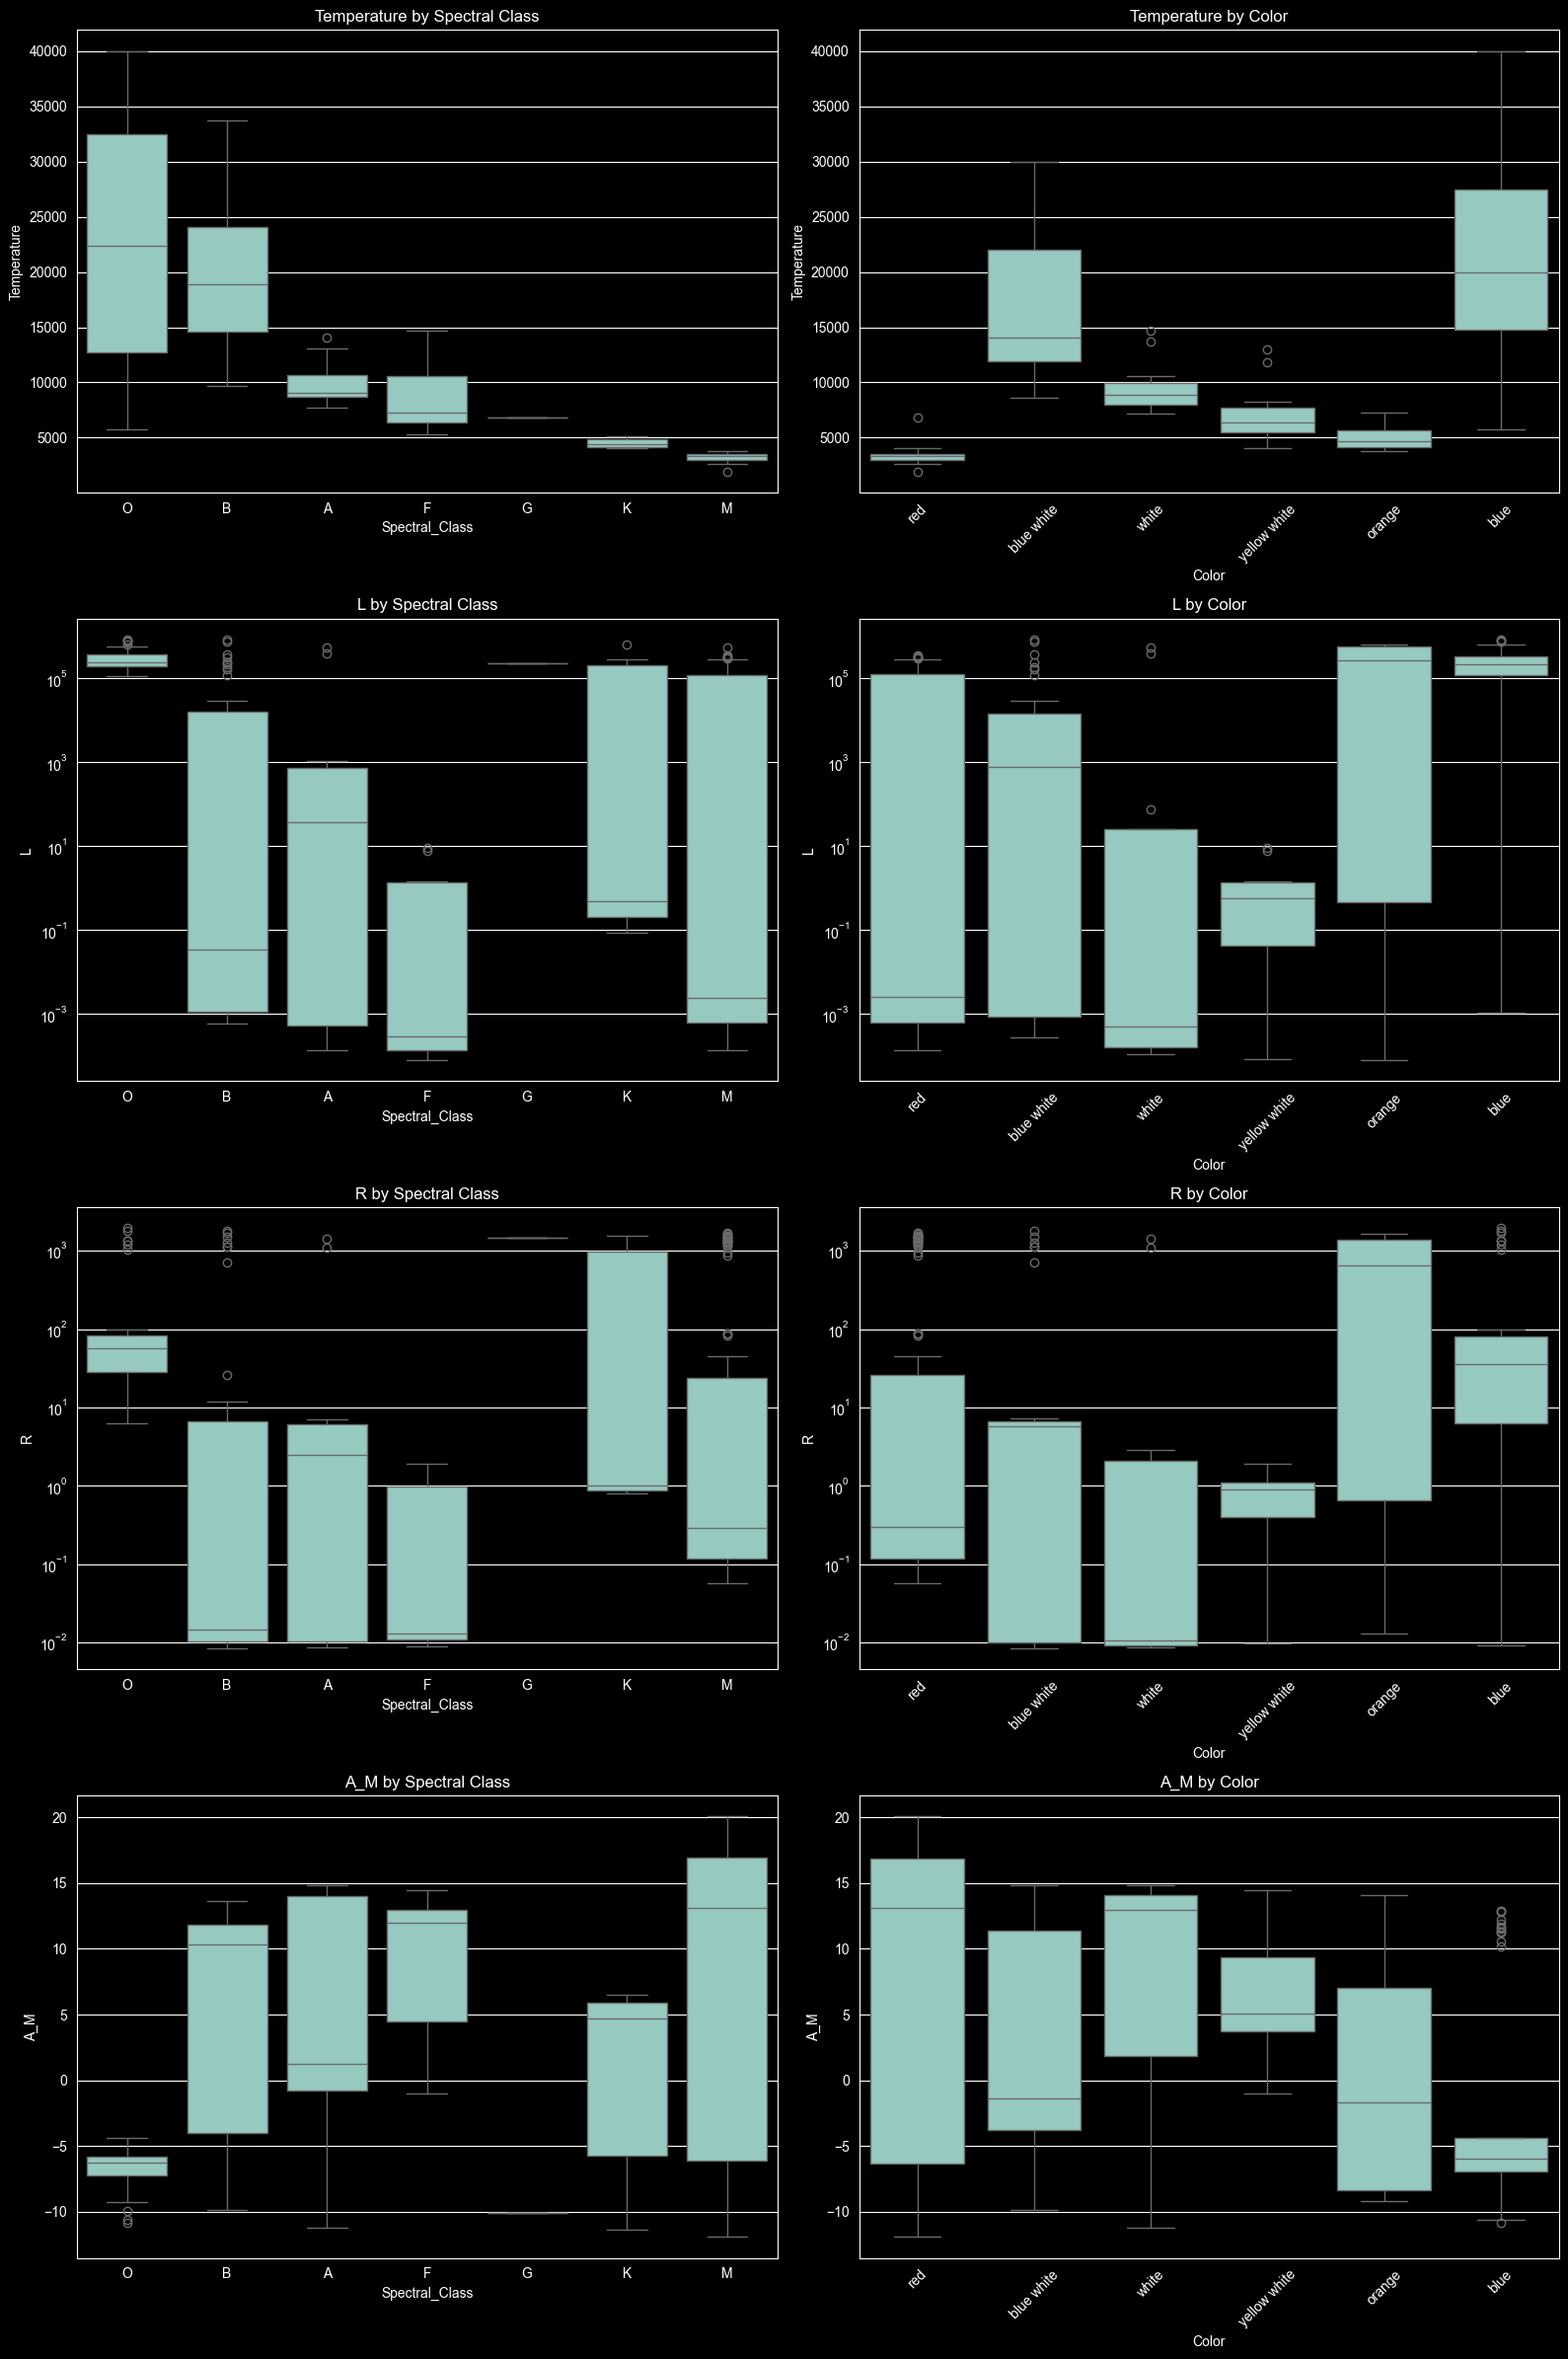

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

for i, col in enumerate(num.columns):
    spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
    sns.boxplot(data=df, x='Spectral_Class', y=col,
            order=spectral_order, ax=axes[i, 0])
    sns.boxplot(data=df, x='Color', y=col, ax=axes[i, 1])

    if col in ['L', 'R']:
        axes[i, 0].set_yscale('log')
        axes[i, 1].set_yscale('log')

    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 0].set_title(f'{col} by Spectral Class')
    axes[i, 1].set_title(f'{col} by Color')

plt.tight_layout()
plt.show()

Observaciones:
* Podemos observar que la media de `Spectral_Class` con `Temperature` va descendiendo. Esto es lo que esperamos, ya que `Spectral_Class` está correlacionada con temperatura, asi que mientras más progresamos por las clases espectrales, menor es a temperatura.
* `L` en base a `Spectral_Class` nos muestra como el grupo O, representando ~16% del dataset, son estrellas de alta luminosidad en mayoría.
    * La relación no es lineal, M, siendo la clase más fría y más representativa (~40%), nos muestra una varianza gigantesca de `L`. Esto tiene sentido, agrupamos estrellas frías y gigantes en la misma categoría que frías y enanas, por lo que la luminosidad varía mucho. Necesitamos `R` y `A_M` en conjunto con `Spectral_Class` para entender la imagen completa.
* En `A_M` y `Spectral_Class` observamos un caso similar que con `L`. El tamaño de la estrella no afecta su brillo cuando es muy caliente, por eso O tiene tan poca varianza y está en un rango donde `A_M` es menor (mayor brillo), igual que con `L`. Estrellas muy calientes son muy brillantes. Ocurre lo mismo con M que en el caso de `L`, no nos da la imagen completa.
* Las estrellas con mayor temperatura son las azules y azules-blancas, estás además representan gran parte de la muestra (~23%, ~17%).
    *  También podemos observar un gradiénte, de temperatura con color: rojo, naranja, amarillo, blanco y azul.
* El color rojo presenta alta varianza en L y R, similar a la clase espectral M, agrupa tanto enanas como supergigantes frías. Las estrellas azules y azul-blancas muestran alta luminosidad consistente con su alta temperatura.

## Conclusiones del EDA

El dataset contiene 240 estrellas con 6 features, 4 numéricas y 2 categóricas, sin valores faltantes.

El análisis muestra que los datos no son homogéneos: existen poblaciones distintas mezcladas en una misma distribución. Esto es visible en las distribuciones multimodales de `Temperature`, `L` y `R`, en la distribución bimodal de `A_M`, y de forma más clara en el diagrama de Hertzsprung-Russell, donde se distinguen 4 grupos naturales correspondientes a hipergigantes/supergigantes, secuencia principal, enanas rojas/marrones y enanas blancas. Esto valida que el problema de clustering tiene estructura en los datos.

`L` y `R` varían en varios órdenes de magnitud, lo que hace que en escala lineal las poblaciones menos representadas queden colapsadas. El diagrama HR confirmó que la escala logarítmica es necesaria para que estas poblaciones sean distinguibles.

Las variables categóricas muestran un gradiente claro: `Spectral_Class` sigue el orden de temperatura $O \to M$, y `Color` sigue un gradiente energético de azul a rojo. Ambos encoding ordinales están justificados. `Color` presentaba inconsistencias de capitalización y formato que fueron corregidas antes del análisis.

Los outliers detectados por IQR no son ruido, son poblaciones poco frecuentes como hipergigantes. No deben eliminarse.

## Implicaciones para El Pre-Procesado

* Había que eliminar clases sucias en `Color`, ya lo hicimos.
* Tenemos que hacer log transform de `L` y `R`.
* Hay que aplicar encoding ordinal en `Spectral_Class` y `Color`, ya que si tienen un orden lógico.
* Usamos `StandardScaler` por el rango gigante de las escalas.
* Hacemos PCA a 2 componentes.

# Pre-Procesado

(240, 2)
Varianza explicada: [0.81067213 0.16071882]
Varianza total: 97.14%


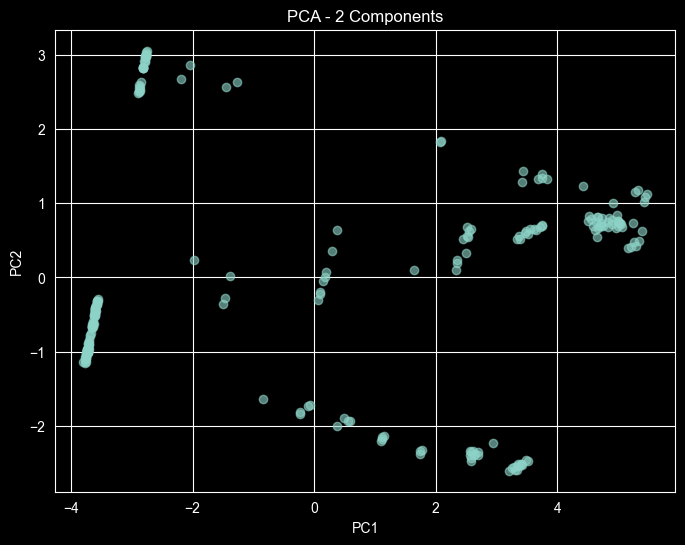

In [14]:

# Initial config.
NIA_SEED = 100502359
np.random.seed(NIA_SEED)

# Log Transform
df['L'] = np.log1p(df['L'])
df['R'] = np.log1p(df['R'])

spectral_order = ['M', 'K', 'G', 'F', 'A', 'B', 'O']
color_order = ['red', 'orange', 'yellow white', 'white', 'blue white', 'blue']

num_vars    = num.columns.tolist()
cat_vars    = cat.columns.tolist()

# Machine for Numbers (Scale)
num_pipeline = Pipeline([
    ('scale', StandardScaler())
])
# Machine for Words (Encode)
cat_pipeline = Pipeline([
    ('encode', OrdinalEncoder(categories=[color_order, spectral_order]))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_vars),
    ('cat', cat_pipeline, cat_vars),
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2, random_state=NIA_SEED))
])

X_pca = full_pipeline.fit_transform(df)
print(X_pca.shape)

pca = full_pipeline.named_steps['pca']
print(f"Varianza explicada: {pca.explained_variance_ratio_}")
print(f"Varianza total: {pca.explained_variance_ratio_.sum():.2%}")
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - 2 Components')
plt.show()

El pre-procesado fue un éxito, con 97% de varianza, mantuvimos casi toda la información al acoplar. PC1 explica el 81% sola, probablemente usa `L`, `R` y `A_M`, y PC2 16%, probablemente usando el resto.

El scatter plot PCA revela 5 grupos visualmente distinguibles, lo que sugiere que K=5 o K=6 son candidatos razonables para los algoritmos de clustering.

# Algoritmos

## K-Means